Starte Lasttest-Generierung (Bronze-Schicht)...
Bronze generiert: 500000 Zeilen mit Fehlern.


machine_id,zeitstempel,motor_temp,drehzahl,kraftstoff_l_h
TR-121,2026-08-25T02:47:49.171Z,83.79,1597,31.25
TR-102,2026-09-08T13:15:33.346Z,78.71,null,30.74
TR-149,2026-08-20T20:12:05.012Z,105.16,2090,21.04
TR-100,2026-09-09T12:32:57.304Z,81.1,1736,27.27
TR-101,2026-09-01T04:58:05.419Z,76.84,1765,21.74
TR-102,2026-09-11T11:48:09.648Z,101.04,2135,15.19
TR-121,2026-09-01T21:40:38.789Z,86.34,1956,23.03
TR-127,2026-09-04T15:19:10.303Z,86.9,2042,33.11
TR-112,2026-08-28T00:40:33.455Z,100.33,1761,26.44
TR-126,2026-08-21T17:22:55.651Z,100.58,2042,27.9


Silber-Schicht fertig! Saubere Datensätze: 470768


machine_id,zeitstempel,motor_temp,drehzahl,kraftstoff_l_h,warnung_ueberhitzung
TR-121,2026-08-25T02:47:50.893Z,83.79,1597,31.25,0
TR-149,2026-08-20T20:12:06.735Z,105.16,2090,21.04,1
TR-100,2026-09-09T12:32:59.026Z,81.1,1736,27.27,0
TR-101,2026-09-01T04:58:07.141Z,76.84,1765,21.74,0
TR-102,2026-09-11T11:48:11.370Z,101.04,2135,15.19,0
TR-121,2026-09-01T21:40:40.511Z,86.34,1956,23.03,0
TR-127,2026-09-04T15:19:12.026Z,86.9,2042,33.11,0
TR-112,2026-08-28T00:40:35.177Z,100.33,1761,26.44,0
TR-126,2026-08-21T17:22:57.373Z,100.58,2042,27.9,0
TR-141,2026-08-25T22:55:17.542Z,79.1,1895,27.79,0


Gold-Schicht fertig! KPI-Übersicht nach Modell:


modell,avg_temperatur,max_temperatur,avg_verbrauch,kritische_ueberhitzungen
Fendt 900 Vario,89.96,137.49,25.0,15433
Fendt 700 Vario,89.99,135.35,24.98,15714


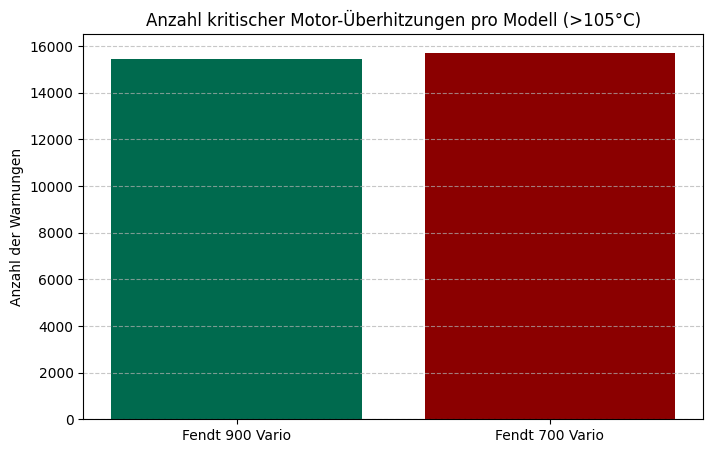

In [0]:
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import pandas as pd

stammdaten = []
for i in range(100, 151):
    # Echte Modellnamen verwenden
    modell = "Fendt 700 Vario" if i % 2 == 0 else "Fendt 900 Vario"
    stammdaten.append((f"TR-{i}", modell, "Allgäu"))

df_stammdaten = spark.createDataFrame(stammdaten, ["machine_id", "modell", "region"])

print("Starte Lasttest-Generierung (Bronze-Schicht)...")

df_roh = spark.range(0, 500000)

# Maschinen-ID und realistische Zeitstempel (letzte 30 Tage) generieren
df_bronze = df_roh.withColumn("machine_id", F.concat(F.lit("TR-"), (F.rand() * 50 + 100).cast("int")))
df_bronze = df_bronze.withColumn("zeitstempel", F.expr("current_timestamp() - INTERVAL 1 DAY * (rand() * 30)"))

# Sensordaten simulieren (Temp, Drehzahl, Kraftstoff)
df_bronze = df_bronze.withColumn("motor_temp", F.round(F.randn() * 10 + 90, 2))
df_bronze = df_bronze.withColumn("drehzahl", (F.randn() * 200 + 1900).cast("int"))
df_bronze = df_bronze.withColumn("kraftstoff_l_h", F.round(F.randn() * 5 + 25, 2))

# Künstliches Chaos für die Bereinigung einbauen!
df_bronze = df_bronze.withColumn("motor_temp", F.when(F.rand() < 0.02, F.lit(-50.0)).otherwise(F.col("motor_temp")))
df_bronze = df_bronze.withColumn("drehzahl", F.when(F.rand() < 0.03, F.lit(None)).otherwise(F.col("drehzahl")))
df_bronze = df_bronze.withColumn("kraftstoff_l_h", F.when(F.rand() < 0.01, F.lit(-99.0)).otherwise(F.col("kraftstoff_l_h")))

df_telemetrie_bronze = df_bronze.drop("id")

print(f"Bronze generiert: {df_telemetrie_bronze.count()} Zeilen mit Fehlern.")
display(df_telemetrie_bronze)


# Fehlerhafte Sensorwerte filtern
df_silver = df_telemetrie_bronze.filter((F.col("motor_temp") >= 0) & (F.col("kraftstoff_l_h") >= 0))
df_silver = df_silver.dropna(subset=["drehzahl"])

# Feature Engineering: Eine Warn-Spalte für kritische Temperaturen hinzufügen
df_silver = df_silver.withColumn("warnung_ueberhitzung", F.when(F.col("motor_temp") > 105.0, 1).otherwise(0))

print(f"Silber-Schicht fertig! Saubere Datensätze: {df_silver.count()}")
display(df_silver)


df_gold = df_silver.join(df_stammdaten, on="machine_id", how="inner")

# Komplexe Aggregation für das Management-Dashboard
df_ergebnis = df_gold.groupBy("modell").agg(
    F.round(F.avg("motor_temp"), 2).alias("avg_temperatur"),
    F.max("motor_temp").alias("max_temperatur"),
    F.round(F.avg("kraftstoff_l_h"), 2).alias("avg_verbrauch"),
    F.sum("warnung_ueberhitzung").alias("kritische_ueberhitzungen")
)

print("Gold-Schicht fertig! KPI-Übersicht nach Modell:")
display(df_ergebnis)


# Spark-Tabelle in lokalen Pandas-DataFrame umwandeln
df_plot = df_ergebnis.toPandas()

# Balkendiagramm für kritische Überhitzungen erstellen
plt.figure(figsize=(8, 5))
plt.bar(df_plot['modell'], df_plot['kritische_ueberhitzungen'], color=['#006a4e', '#8b0000']) # Fendt-Grün vs Rot
plt.title('Anzahl kritischer Motor-Überhitzungen pro Modell (>105°C)')
plt.ylabel('Anzahl der Warnungen')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Diagramm in Databricks anzeigen
plt.show()